# Comparación de modelos

Carga los resultados guardados por cada notebook individual y genera la tabla y figura final.

In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
RESULTS_BASE = '../results'
K_VALUES = [5, 10, 20]

## 1. Cargar todos los resultados

In [2]:
MODELS = ['random', 'mostpopular', 'svd', 'textcf', 'visualcf', 'mmgcn_tmc', "mmgcn"]
DISPLAY_NAMES = {
    'random': 'Random',
    'mostpopular': 'MostPopular',
    'svd': 'SVD',
    'textcf': 'TextCF',
    'visualcf': 'VisualCF (CLIP)',
    'mmgcn_tmc': 'MMGCN-TMC',
    'mmgcn': 'MMGCN'
}

all_metrics = {}
for model in MODELS:
    path = os.path.join(RESULTS_BASE, model, 'metrics.csv')
    if os.path.exists(path):
        df = pd.read_csv(path, index_col='K')
        all_metrics[DISPLAY_NAMES[model]] = df
        print(f'{DISPLAY_NAMES[model]} está listo')
    else:
        print(f'No se encontró el archivo de métricas para {DISPLAY_NAMES[model]} en {path}')

Random está listo
MostPopular está listo
SVD está listo
TextCF está listo
VisualCF (CLIP) está listo
MMGCN-TMC está listo
MMGCN está listo


## 2. Tabla resumen en K=10

In [3]:
rows = []
for name, df in all_metrics.items():
    row = df.loc[10].to_dict()
    row['model'] = name
    rows.append(row)

summary = pd.DataFrame(rows).set_index('model')[['precision', 'recall', 'ndcg']]
summary.columns = ['Precision@10', 'Recall@10', 'NDCG@10']
summary = summary.sort_values('NDCG@10', ascending=False)

print('=== Tabla comparativa K=10 ===')
print(summary.round(4).to_string())

summary.round(4).to_csv('../results/summary_k10.csv')
print('\nGuardado: results/summary_k10.csv')

=== Tabla comparativa K=10 ===
                 Precision@10  Recall@10  NDCG@10
model                                            
MMGCN                  0.0233     0.1538   0.0883
MMGCN-TMC              0.0222     0.1458   0.0829
VisualCF (CLIP)        0.0210     0.1351   0.0761
SVD                    0.0204     0.1326   0.0749
TextCF                 0.0170     0.1049   0.0619
MostPopular            0.0077     0.0506   0.0287
Random                 0.0012     0.0077   0.0038

Guardado: results/summary_k10.csv


## 3. Figura de curvas P@K / R@K / NDCG@K

Figura guardada: results/comparison.png


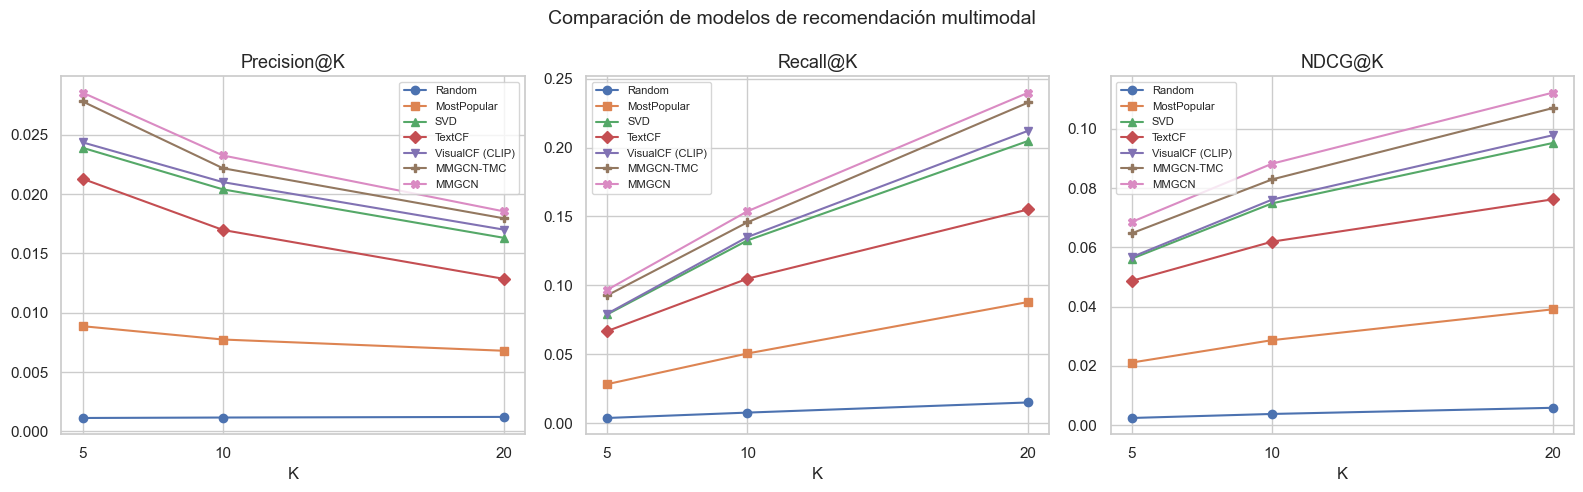

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metric_cols = ['precision', 'recall', 'ndcg']
titles = ['Precision@K', 'Recall@K', 'NDCG@K']
styles = ['-o', '-s', '-^', '-D', '-v', '-P', '-X']

for ax, col, title in zip(axes, metric_cols, titles):
    for (name, df), style in zip(all_metrics.items(), styles):
        ax.plot(df.index, df[col], style, label=name, linewidth=1.5, markersize=6)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('K')
    ax.set_xticks(K_VALUES)
    ax.legend(fontsize=8)

plt.suptitle('Comparación de modelos de recomendación multimodal', fontsize=14)
plt.tight_layout()
plt.savefig('../results/comparison.png', dpi=150, bbox_inches='tight')
print('Figura guardada: results/comparison.png')

## 4. Configs de cada modelo

In [5]:
for model in MODELS:
    config_path = os.path.join(RESULTS_BASE, model, 'config.json')
    if os.path.exists(config_path):
        with open(config_path) as f:
            print(json.dumps(json.load(f), indent=2))
        print()

{
  "model": "SVD",
  "n_factors": 50,
  "random_state": 42,
  "library": "sklearn.decomposition.TruncatedSVD"
}

{
  "model": "TextCF",
  "alpha": 0.5,
  "n_factors": 50,
  "sbert_model": "all-MiniLM-L6-v2",
  "like_threshold": 4.0
}

{
  "model": "VisualCF",
  "alpha": 0.5,
  "n_factors": 50,
  "image_model": "CLIP (512d)",
  "like_threshold": 4.0
}

{
  "model": "MMGCN_TMC",
  "embed_dim": 64,
  "dim_latent_v": 256,
  "evidence_dim": 16,
  "aggr_mode": "mean",
  "concate": false,
  "has_id": true,
  "epochs": 50,
  "lr": 0.0001,
  "weight_decay": 1e-05,
  "_kl": 0.1,
  "annealing_step": 10,
  "batch_size": 1024,
  "like_threshold": 4.0,
  "image_model": "CLIP (512d)",
  "text_model": "all-MiniLM-L6-v2",
  "loss": "BPR + KL-DS + L2 reg",
  "fusion": "Dempster-Shafer (TMC, Han et al. TPAMI 2023)",
  "fusion_ref": "DOI: 10.1109/TPAMI.2022.3171983",
  "gcn_layers": 3,
  "n_items_multimodal": 1151,
  "n_users": 10490
}

{
  "model": "MMGCN",
  "embed_dim": 64,
  "dim_latent_v": 256,
  "a